# Linear Regression: an eight-chapter Bike Sharing experiment

This notebook preserves chronological order. Exploration, scaling, and feature selection all avoid the test set.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = next(path for path in (
    Path('../../datasets/python-data-tools/bike-sharing-hour.csv'),
    Path('../../../datasets/python-data-tools/bike-sharing-hour.csv'),
    Path('.build-input.csv'),
) if path.exists())
data = pd.read_csv(DATA_PATH)
data['dteday'] = pd.to_datetime(data['dteday'])
data['timestamp'] = data['dteday'] + pd.to_timedelta(data['hr'], unit='h')
train = data.iloc[:10427].copy()
validation = data.iloc[10427:13903].copy()
test = data.iloc[13903:].copy()
print({'train': len(train), 'validation': len(validation), 'test': len(test)})

{'train': 10427, 'validation': 3476, 'test': 3476}


{'intercept': 16.61, 'slope': 278.863, 'prediction_at_temp_0.5': 156.042}


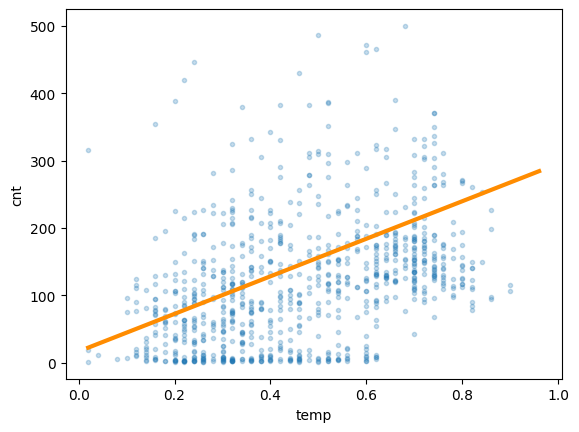

In [2]:
line = LinearRegression().fit(train[['temp']], train['cnt'])
single_prediction = float(line.predict(pd.DataFrame({'temp': [0.5]}))[0])
print({'intercept': round(float(line.intercept_), 3), 'slope': round(float(line.coef_[0]), 3), 'prediction_at_temp_0.5': round(single_prediction, 3)})
sample = train.iloc[::12]
grid = np.linspace(train['temp'].min(), train['temp'].max(), 160)
plt.scatter(sample['temp'], sample['cnt'], s=9, alpha=.25)
plt.plot(grid, line.predict(pd.DataFrame({'temp': grid})), color='darkorange', linewidth=3)
plt.xlabel('temp'); plt.ylabel('cnt'); plt.show()

In [3]:
print(train[['instant', 'timestamp', 'temp', 'hum', 'windspeed', 'workingday', 'hr', 'cnt']].head())
print('leakage identity:', bool((data['casual'] + data['registered'] == data['cnt']).all()))
print('ranges:', train['instant'].iloc[[0, -1]].tolist(), validation['instant'].iloc[[0, -1]].tolist(), test['instant'].iloc[[0, -1]].tolist())

   instant           timestamp  temp   hum  windspeed  workingday  hr  cnt
0        1 2011-01-01 00:00:00  0.24  0.81        0.0           0   0   16
1        2 2011-01-01 01:00:00  0.22  0.80        0.0           0   1   40
2        3 2011-01-01 02:00:00  0.22  0.80        0.0           0   2   32
3        4 2011-01-01 03:00:00  0.24  0.75        0.0           0   3   13
4        5 2011-01-01 04:00:00  0.24  0.75        0.0           0   4    1
leakage identity: True
ranges: [1, 10427] [10428, 13903] [13904, 17379]


In [4]:
print(train[['temp', 'hum', 'windspeed', 'workingday', 'hr', 'cnt']].describe().round(3))
print(train[['temp', 'hum', 'windspeed', 'workingday', 'hr', 'cnt']].corr().round(3))

            temp        hum  windspeed  workingday         hr        cnt
count  10427.000  10427.000  10427.000   10427.000  10427.000  10427.000
mean       0.460      0.631      0.196       0.683     11.561    144.797
std        0.197      0.198      0.126       0.465      6.908    134.621
min        0.020      0.000      0.000       0.000      0.000      1.000
25%        0.300      0.470      0.104       0.000      6.000     32.000
50%        0.440      0.620      0.194       1.000     12.000    110.000
75%        0.620      0.790      0.284       1.000     18.000    213.000
max        0.960      1.000      0.851       1.000     23.000    782.000
             temp    hum  windspeed  workingday     hr    cnt
temp        1.000 -0.004     -0.016       0.071  0.126  0.409
hum        -0.004  1.000     -0.293       0.042 -0.254 -0.286
windspeed  -0.016 -0.293      1.000      -0.010  0.131  0.092
workingday  0.071  0.042     -0.010       1.000  0.002  0.030
hr          0.126 -0.254      0.1

In [5]:
train_prediction = line.predict(train[['temp']])
residual = train_prediction - train['cnt'].to_numpy()
metrics = {'MSE': mean_squared_error(train['cnt'], train_prediction), 'RMSE': mean_squared_error(train['cnt'], train_prediction) ** .5, 'MAE': mean_absolute_error(train['cnt'], train_prediction), 'R2': r2_score(train['cnt'], train_prediction)}
print({key: round(float(value), 3) for key, value in metrics.items()})
print('largest absolute residual:', round(float(np.abs(residual).max()), 3))

{'MSE': 15091.549, 'RMSE': 122.848, 'MAE': 94.54, 'R2': 0.167}
largest absolute residual: 570.186


In [6]:
features = ['temp', 'hum', 'windspeed', 'workingday', 'hr']
scaler = StandardScaler().fit(train[['temp', 'hum', 'windspeed', 'hr']])
print('train-only scaler mean:', np.round(scaler.mean_, 4))
print('The published gradient-descent-trace.csv records the NumPy optimization and sklearn agreement.')

train-only scaler mean: [ 0.4597  0.6307  0.1956 11.5608]
The published gradient-descent-trace.csv records the NumPy optimization and sklearn agreement.


In [7]:
hourly = train.groupby(['workingday', 'hr'])['cnt'].mean().unstack(0)
print(hourly.round(2).head(8))
angle = 2 * np.pi * train['hr'] / 24
print(pd.DataFrame({'hr': train['hr'].head(), 'sin_hr': np.sin(angle.head()), 'cos_hr': np.cos(angle.head())}).round(3))

workingday      0       1
hr                       
0           70.41   28.59
1           53.37   13.23
2           42.85    7.24
3           21.48    4.19
4            6.55    4.37
5            6.71   18.41
6           12.79   78.96
7           30.37  220.85
   hr  sin_hr  cos_hr
0   0   0.000   1.000
1   1   0.259   0.966
2   2   0.500   0.866
3   3   0.707   0.707
4   4   0.866   0.500


In [8]:
stage_metrics = pd.read_csv('feature-stage-metrics.csv')
print(stage_metrics.round(3).to_string(index=False))

              stage_id  order  feature_count_before_encoding estimator  alpha  includes_atemp  train_mse  train_rmse  train_mae  train_r2  validation_mse  validation_rmse  validation_mae  validation_r2
      temperature-only      0                              1       ols    NaN           False  15091.549     122.848     94.540     0.167       48060.525          219.227         166.661         -0.035
             core-five      1                              5       ols    NaN           False  12080.871     109.913     81.827     0.333       39124.361          197.799         141.125          0.157
   calendar-categories      2                             11       ols    NaN           False  11213.482     105.894     79.956     0.381       33241.025          182.321         141.218          0.284
calendar-weather-cycle      3                             14       ols    NaN           False   9089.189      95.337     69.965     0.498       27839.071          166.850         127.004      

In [9]:
summary = pd.read_json('linear-regression-course-summary.json', typ='series')
print('Selected stage:', summary['selection']['selectedStageId'])
print('Interpret coefficients only after checking scaling and encoding; association is not causation.')

Selected stage: calendar-weather-cycle
Interpret coefficients only after checking scaling and encoding; association is not causation.


In [10]:
residuals = pd.read_csv('test-residuals.csv')
print(residuals[['actual', 'prediction', 'residual']].describe().round(3))
print('Named failure cases are published in the summary JSON.')

         actual  prediction  residual
count  3476.000    3476.000  3476.000
mean    248.755     246.349    -2.406
std     220.517     106.091   163.117
min       1.000     -34.063  -606.378
25%      53.000     159.223   -56.195
50%     205.000     242.187    51.072
75%     367.000     336.581   107.424
max     977.000     465.066   273.521
Named failure cases are published in the summary JSON.


In [11]:
print('temp/atemp training correlation:', round(float(train[['temp', 'atemp']].corr().iloc[0, 1]), 4))
print('Ridge shares shrinkage across correlated variables; Lasso can set coefficients exactly to zero.')

temp/atemp training correlation: 0.992
Ridge shares shrinkage across correlated variables; Lasso can set coefficients exactly to zero.


In [12]:
final_metrics = summary['finalTest']['metrics']
print({key: round(float(value), 3) for key, value in final_metrics.items()})
print('The test partition was evaluated once after feature and regularization decisions were frozen.')

{'mse': 26605.249, 'rmse': 163.111, 'mae': 120.989, 'r2': 0.453}
The test partition was evaluated once after feature and regularization decisions were frozen.
